In [2]:
# =============================================================================
# Imports
# =============================================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_DIR = Path("datasets/radar_statistics")
FIGURES = Path("figures/notebook09")

FIGURES.mkdir(
    parents=True,
    exist_ok=True,
)

events = pd.read_parquet(
    DATA_DIR / "extreme_events.parquet"
)

events["timestamp"] = pd.to_datetime(
    events.timestamp
)

events["year"] = events.timestamp.dt.year
events["month"] = events.timestamp.dt.month
events["hour"] = events.timestamp.dt.hour

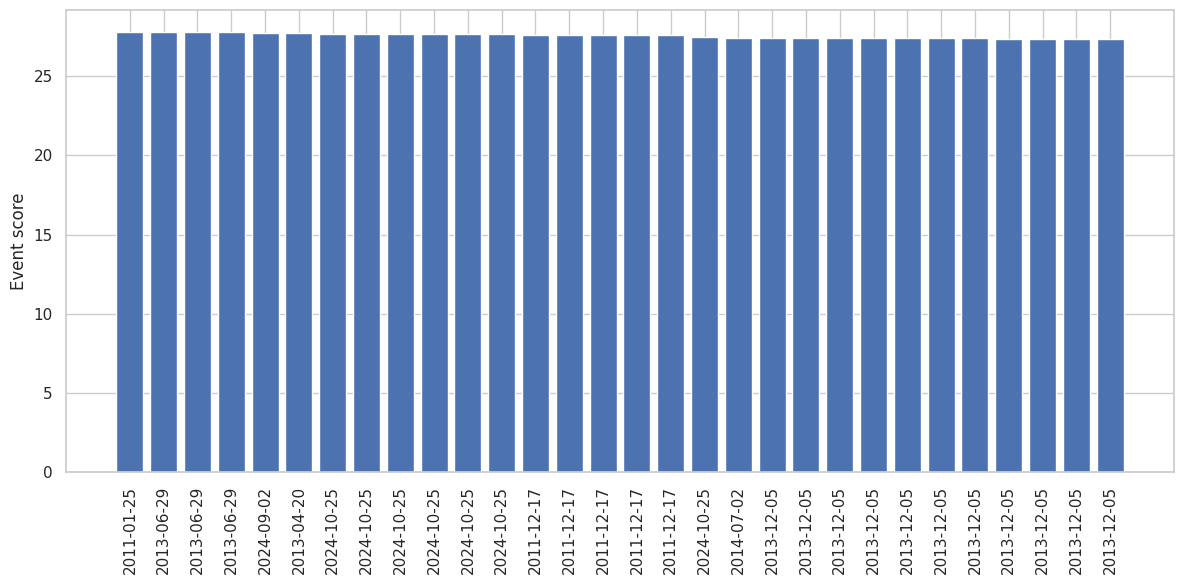

In [3]:
top30 = events.nlargest(
    30,
    "event_rank"
)

plt.figure(figsize=(12,6))

plt.bar(
    range(len(top30)),
    top30.event_rank
)

plt.xticks(
    range(len(top30)),
    top30.timestamp.dt.strftime("%Y-%m-%d"),
    rotation=90
)

plt.ylabel("Event score")

plt.tight_layout()

plt.savefig(
    FIGURES/"top30_events.png",
    dpi=300
)

plt.show()

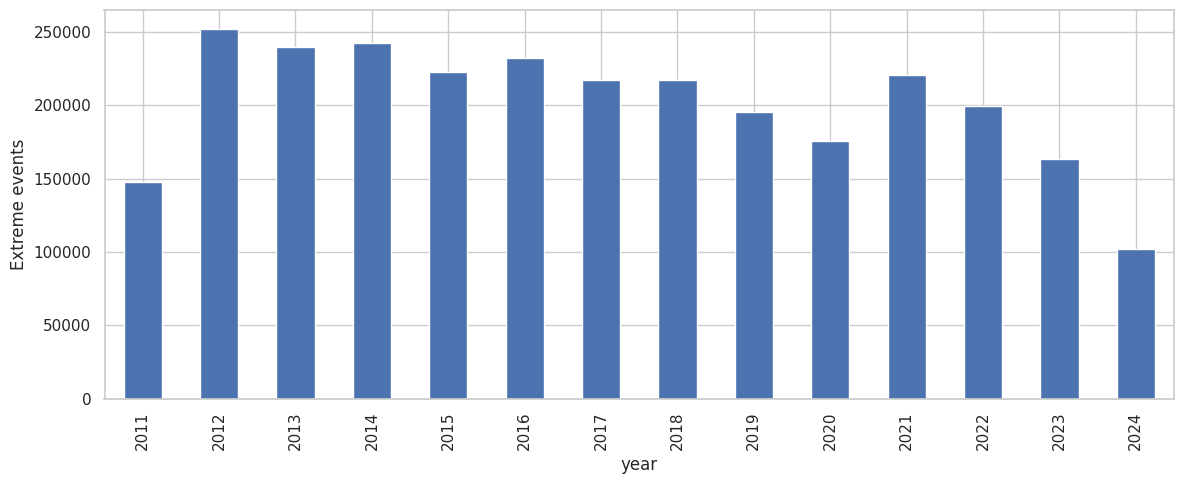

In [4]:
yearly = (
    events
    .groupby("year")
    .size()
)

plt.figure(figsize=(12,5))

yearly.plot.bar()

plt.ylabel("Extreme events")

plt.tight_layout()

plt.savefig(
    FIGURES/"events_per_year.png",
    dpi=300
)

plt.show()

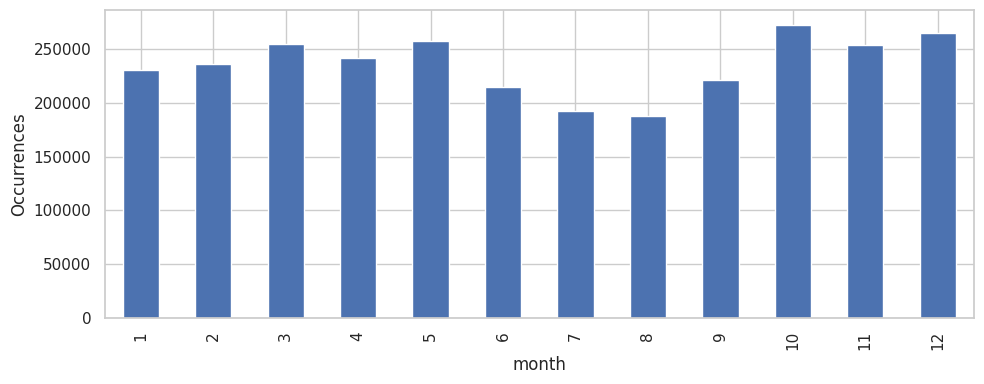

In [5]:
monthly = (
    events
    .groupby("month")
    .size()
)

plt.figure(figsize=(10,4))

monthly.plot.bar()

plt.ylabel("Occurrences")

plt.tight_layout()

plt.savefig(
    FIGURES/"events_per_month.png",
    dpi=300
)

plt.show()

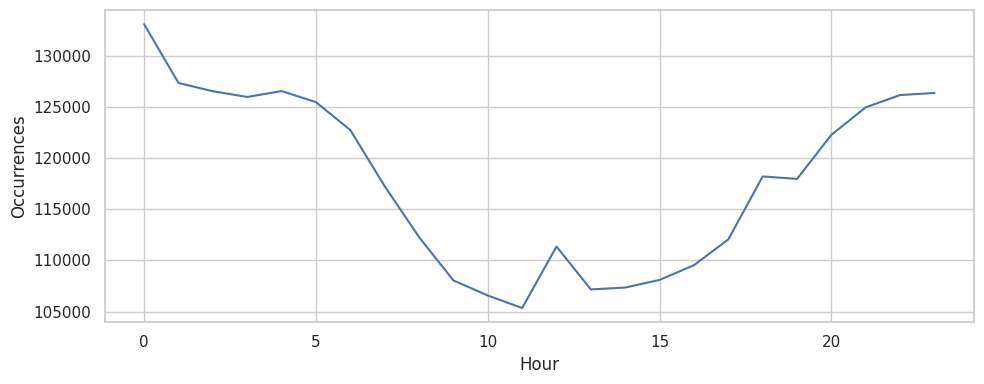

In [6]:
hourly = (
    events
    .groupby("hour")
    .size()
)

plt.figure(figsize=(10,4))

hourly.plot()

plt.ylabel("Occurrences")

plt.xlabel("Hour")

plt.tight_layout()

plt.savefig(
    FIGURES/"events_hour.png",
    dpi=300
)

plt.show()

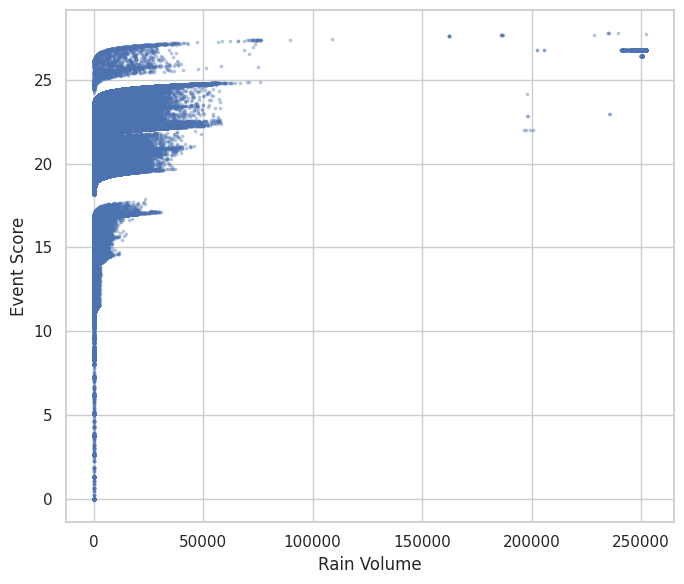

In [8]:
plt.figure(figsize=(7,6))

plt.scatter(
    events.volume,
    events.event_rank,
    s=3,
    alpha=0.3
)

plt.xlabel("Rain Volume")

plt.ylabel("Event Score")

plt.tight_layout()

plt.savefig(
    FIGURES/"event_score_vs_volume.png",
    dpi=300
)

plt.show()

In [9]:
events.sort_values(
    "event_rank",
    ascending=False
).head(20)

,timestamp,max_reflectivity,rain_pixels,rain_fraction,volume,mean,event_rank,year,month,hour
0,2011-01-25 08:02:00,50.000000,5880,1.000000,239276.593750,40.693298,27.777076,2011,1,8
1,2013-06-29 17:52:00,50.000000,5880,1.000000,235270.468750,40.011986,27.773699,2013,6,17
2,2013-06-29 17:50:00,50.000000,5880,1.000000,235073.812500,39.978539,27.773532,2013,6,17
3,2013-06-29 17:48:00,50.000000,5880,1.000000,234874.671875,39.944672,27.773362,2013,6,17
4,2024-09-02 02:38:00,49.868866,5880,1.000000,252331.500000,42.913521,27.722134,2024,9,2
5,2013-04-20 10:26:00,50.000000,4574,0.777891,228645.000000,49.987976,27.701353,2013,4,10
6,2024-10-25 13:06:00,50.000000,4389,0.746429,186798.875000,42.560692,27.651487,2024,10,13
7,2024-10-25 13:14:00,50.000000,4388,0.746259,186471.765625,42.495846,27.651086,2024,10,13
8,2024-10-25 13:10:00,50.000000,4388,0.746259,186298.906250,42.456451,27.650900,2024,10,13
9,2024-10-25 13:12:00,50.000000,4387,0.746088,186289.265625,42.463932,27.650839,2024,10,13
